In [ ]:
# Importing Libraries we're gonna need through out the project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_excel("online_retail_II.xlsx") # Loading Data
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [ ]:
df.info() # Taking a look at basis info

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [ ]:
df.describe() # Taking a look at statistical summary of data

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845018,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [ ]:
df.describe(include="O") #looking into statistical summary of Object type data

C:\Users\Alvi\AppData\Local\Temp\ipykernel_13552\504318277.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="O")


,Invoice,StockCode,Description,Country
count,525461,525461,522533,525461
unique,28816,4632,4681,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,675,3516,3549,485852


In [ ]:
df[df["Customer ID"].isna()].head(10) #Checking where Customer Id is missing

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [7]:
df[df["Quantity"]<0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [ ]:
df["Invoice"] = df["Invoice"].astype("str")
df[df["Invoice"].str.match(("^\\d{6}$"))==False]  # Checking where Invoice doesn't meet 6 didgits format

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.0,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.0,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.0,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.0,United Kingdom


- Here 'C' in invoiceID shows that order was cancelled  

In [ ]:
df["Invoice"].str.replace("[0-9]","",regex=True).unique() #Checking if Invoice has any  charactor other than 'C'

<StringArray>
['', 'C', 'A']
Length: 3, dtype: str

In [ ]:
df[df["Invoice"].str.startswith("A")] #Checking how many values start with 'A'

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


- There are very few values starting with 'A'

In [11]:
df["StockCode"] = df["StockCode"].astype("str")
df[(df["StockCode"].str.match("^\\d{5}$")==False) & (df["StockCode"].str.match("^\\d{5}[a-zA-Z]+$")==False)]["StockCode"].unique()

<StringArray>
[        'POST',            'D',     'DCGS0058',     'DCGS0068',
          'DOT',            'M',     'DCGS0004',     'DCGS0076',
           'C2', 'BANK CHARGES',     'DCGS0003',      'TEST001',
 'gift_0001_80',     'DCGS0072', 'gift_0001_20',     'DCGS0044',
      'TEST002', 'gift_0001_10', 'gift_0001_50',    'DCGS0066N',
 'gift_0001_30',         'PADS',       'ADJUST', 'gift_0001_40',
 'gift_0001_60', 'gift_0001_70', 'gift_0001_90',    'DCGSSGIRL',
     'DCGS0006',     'DCGS0016',     'DCGS0027',     'DCGS0036',
     'DCGS0039',     'DCGS0060',     'DCGS0056',     'DCGS0059',
         'GIFT',     'DCGSLBOY',            'm',     'DCGS0053',
     'DCGS0062',     'DCGS0037',     'DCGSSBOY',    'DCGSLGIRL',
            'S',     'DCGS0069',     'DCGS0070',     'DCGS0075',
            'B',     'DCGS0041',      'ADJUST2',      '47503J ',
           'C3',       'SP1002',    'AMAZONFEE']
Length: 55, dtype: str

## Data Cleaning

In [12]:
cleaned_df = df.copy()

In [ ]:
cleaned_df["Invoice"] = cleaned_df["Invoice"].astype("str")
mask = (
    cleaned_df["Invoice"].str.match("^\\d{6}$") == True
)
cleaned_df = cleaned_df[mask] # Dropping Invoice which doesn't meet 6 digit format(Contain 'C')
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [ ]:
cleaned_df["StockCode"] = cleaned_df["StockCode"].astype("str")
mask = (
    (cleaned_df["StockCode"].str.match("^\\d{5}$") == True)|
    (cleaned_df["StockCode"].str.match("^\\d{6}[a-zA-Z]+$") == True)|
    (cleaned_df["StockCode"].str.match("^PADS$")==True)
)
cleaned_df = cleaned_df[mask] # Droppiing rows which do not contain given format or PADS
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [ ]:
cleaned_df.dropna(subset=["Customer ID"],inplace=True) # Data without customer IDs is not appropriate for analysis so dropping it 

In [16]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,350943.000000,350943,350943.000000,350943.000000
mean,13.699606,2010-07-05 17:09:34.748548,2.979564,15360.244439
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-03-31 17:29:00,1.250000,13985.000000
50%,5.000000,2010-07-18 13:42:00,1.950000,15311.000000
75%,12.000000,2010-10-17 14:26:00,3.750000,16797.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,100.074815,NaN,4.424673,1678.202935


In [17]:
len(cleaned_df[cleaned_df["Price"]==0]["Price"])

27

In [ ]:
cleaned_df = cleaned_df[cleaned_df["Price"]>0] # Dropping invalid Price (less than zero)
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [19]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,350916.000000,350916,350916.000000,350916.000000
mean,13.700059,2010-07-05 17:14:15.798310,2.979794,15360.352694
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000
25%,2.000000,2010-03-31 17:29:00,1.250000,13985.000000
50%,5.000000,2010-07-18 13:42:00,1.950000,15311.000000
75%,12.000000,2010-10-17 14:26:00,3.750000,16797.000000
max,19152.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,100.078594,NaN,4.424766,1678.162970


In [20]:
len(cleaned_df)/len(df)


0.667825014606222

- We've lsot 34% data in Data Cleaning

# Feature Engineering

In [21]:
cleaned_df["SalesLineTotal"] = cleaned_df["Quantity"] * cleaned_df["Price"]
cleaned_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SalesLineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.60
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50


In [ ]:
# Calculating Monetary Value, Frequency and Last Invoice Date of each unique customer
aggreagated_df = cleaned_df.groupby("Customer ID",as_index=False).agg(
    MonetaryValue = ("SalesLineTotal","sum"),
    Frequency = ("Invoice","nunique"),
    LastInvoiceDate = ("InvoiceDate","max")

) 

aggreagated_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.0,144.02,2,2010-06-28 13:53:00
1,12347.0,966.87,2,2010-12-07 14:57:00
2,12348.0,221.16,1,2010-09-27 14:59:00
3,12349.0,1946.64,2,2010-10-28 08:23:00
4,12351.0,300.93,1,2010-11-29 15:23:00
...,...,...,...,...
4243,18283.0,563.19,6,2010-11-22 15:30:00
4244,18284.0,391.28,1,2010-10-04 11:33:00
4245,18285.0,361.10,1,2010-02-17 10:24:00
4246,18286.0,948.30,2,2010-08-20 11:57:00


In [23]:
max_invoice_date = aggreagated_df["LastInvoiceDate"].max()
max_invoice_date

Timestamp('2010-12-09 20:01:00')

In [24]:
aggreagated_df["Recency"] = max_invoice_date - aggreagated_df["LastInvoiceDate"]
aggreagated_df["Recency"] = aggreagated_df["Recency"].dt.days

In [25]:
aggreagated_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,144.02,2,2010-06-28 13:53:00,164
1,12347.0,966.87,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,1946.64,2,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10
...,...,...,...,...,...
4243,18283.0,563.19,6,2010-11-22 15:30:00,17
4244,18284.0,391.28,1,2010-10-04 11:33:00,66
4245,18285.0,361.10,1,2010-02-17 10:24:00,295
4246,18286.0,948.30,2,2010-08-20 11:57:00,111


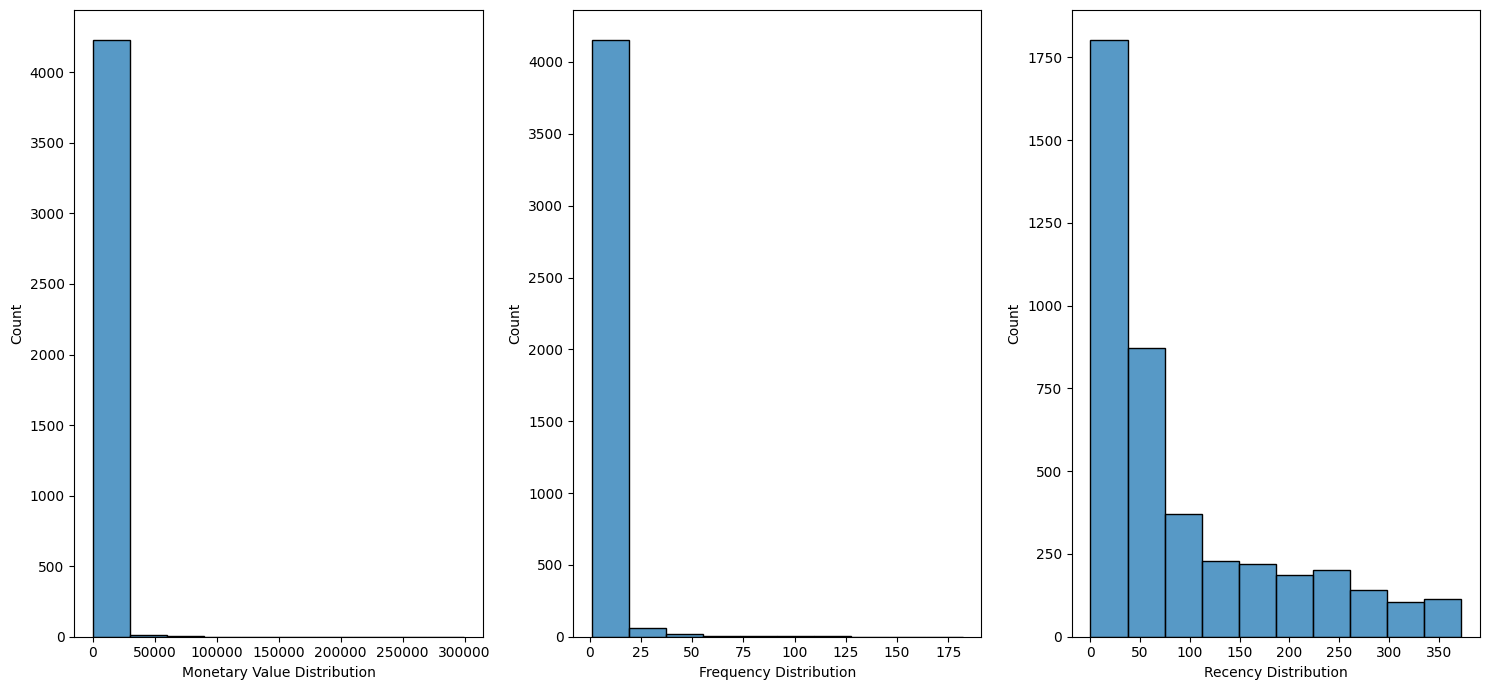

In [26]:
plt.figure(figsize=(15,7))
plt.subplot(1,3,1)
sns.histplot(aggreagated_df["MonetaryValue"],bins=10)
plt.xlabel("Monetary Value Distribution")
plt.ylabel("Count")

plt.subplot(1,3,2)
sns.histplot(aggreagated_df["Frequency"],bins=10)
plt.xlabel("Frequency Distribution")
plt.ylabel("Count")

plt.subplot(1,3,3)
sns.histplot(aggreagated_df["Recency"],bins=10)
plt.xlabel("Recency Distribution")
plt.ylabel("Count")


plt.tight_layout()
plt.show()

- Fig shows that Recency is normally distributed while Monetary Value and Frequency have outliers

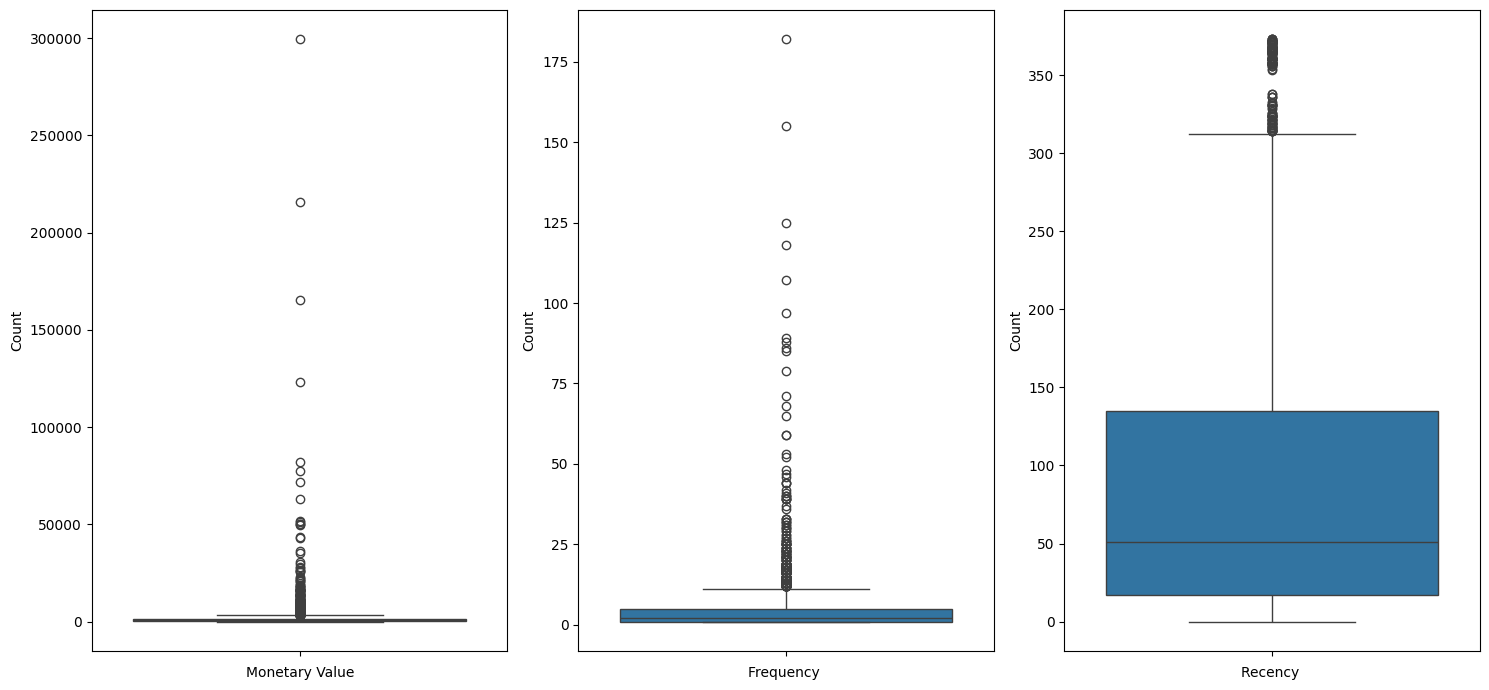

In [27]:
plt.figure(figsize=(15,7))
plt.subplot(1,3,1)
sns.boxplot(aggreagated_df["MonetaryValue"])
plt.xlabel("Monetary Value")
plt.ylabel("Count")

plt.subplot(1,3,2)
sns.boxplot(aggreagated_df["Frequency"])
plt.xlabel("Frequency ")
plt.ylabel("Count")

plt.subplot(1,3,3)
sns.boxplot(aggreagated_df["Recency"])
plt.xlabel("Recency ")
plt.ylabel("Count")


plt.tight_layout()
plt.show()

In [28]:
Q1 = aggreagated_df["MonetaryValue"].quantile(0.25)
Q3 = aggreagated_df["MonetaryValue"].quantile(0.75)
IQR = Q3 - Q1
monetary_outlier_df = aggreagated_df[(aggreagated_df["MonetaryValue"]>(Q3 + (IQR * 1.5))) | (aggreagated_df["MonetaryValue"]<(Q1 - (IQR * 1.5)))].copy()
monetary_outlier_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,412.000000,412.000000,412.000000,412,412.000000
mean,15083.296117,10433.185937,17.033981,2010-11-10 21:01:28.106796,28.674757
min,12357.000000,3308.900000,1.000000,2009-12-10 18:03:00,0.000000
25%,13561.750000,3957.300000,8.000000,2010-11-08 13:45:45,3.000000
50%,14956.500000,5389.850000,12.000000,2010-11-26 15:03:30,13.000000
75%,16653.000000,8847.182500,18.000000,2010-12-06 12:47:30,31.000000
max,18260.000000,299485.800000,182.000000,2010-12-09 19:32:00,364.000000
std,1733.822102,22291.545824,19.376882,NaN,49.154417


In [29]:
Q1 = aggreagated_df["Frequency"].quantile(0.25)
Q3 = aggreagated_df["Frequency"].quantile(0.75)
IQR = Q3 - Q1
freq_outlier_df = aggreagated_df[(aggreagated_df["Frequency"]>(Q3 + (IQR * 1.5))) | (aggreagated_df["Frequency"]<(Q1 - (IQR * 1.5)))].copy()
freq_outlier_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,269.000000,269.000000,269.000000,269,269.000000
mean,15392.802974,12298.980725,23.698885,2010-11-23 16:23:39.033457,15.866171
min,12437.000000,898.140000,12.000000,2010-05-12 16:51:00,0.000000
25%,13831.000000,3638.010000,13.000000,2010-11-21 10:38:00,2.000000
50%,15527.000000,5572.670000,17.000000,2010-12-02 12:09:00,7.000000
75%,16883.000000,10269.460000,24.000000,2010-12-07 12:43:00,18.000000
max,18260.000000,299485.800000,182.000000,2010-12-09 19:32:00,211.000000
std,1748.380712,27198.754282,21.578787,NaN,26.789616


In [30]:
Q1 = aggreagated_df["Recency"].quantile(0.25)
Q3 = aggreagated_df["Recency"].quantile(0.75)
IQR = Q3 - Q1
recency_outlier_df = aggreagated_df[(aggreagated_df["Recency"]>(Q3 + (IQR * 1.5))) | (aggreagated_df["Recency"]<(Q1 - (IQR * 1.5)))].copy()
recency_outlier_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,167.000000,167.000000,167.000000,167,167.000000
mean,15401.508982,307.531204,1.245509,2009-12-24 02:49:12.934131,350.431138
min,12439.000000,2.950000,1.000000,2009-12-01 12:55:00,314.000000
25%,14115.500000,101.400000,1.000000,2009-12-07 13:28:00,327.000000
50%,15380.000000,183.080000,1.000000,2009-12-14 16:11:00,360.000000
75%,16782.500000,313.605000,1.000000,2010-01-16 13:27:30,367.000000
max,18201.000000,4825.680000,6.000000,2010-01-29 14:22:00,373.000000
std,1620.566768,529.119527,0.756236,NaN,20.647494


In [31]:
non_outlier_df = aggreagated_df[(~aggreagated_df.index.isin(monetary_outlier_df.index))&(~aggreagated_df.index.isin(recency_outlier_df.index))&(~aggreagated_df.index.isin(freq_outlier_df.index))]

non_outlier_df.describe()


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3620.000000,3620.000000,3620.000000,3620,3620.000000
mean,15370.587017,796.512977,2.931492,2010-09-15 03:52:01.508287,85.391436
min,12346.000000,3.750000,1.000000,2010-01-31 12:19:00,0.000000
25%,13896.750000,250.522500,1.000000,2010-08-02 14:12:30,21.000000
50%,15378.500000,535.505000,2.000000,2010-10-15 13:49:00,55.000000
75%,16849.500000,1138.480000,4.000000,2010-11-18 13:18:45,129.000000
max,18287.000000,3298.600000,11.000000,2010-12-09 20:01:00,312.000000
std,1694.928260,718.882255,2.250112,NaN,83.562242


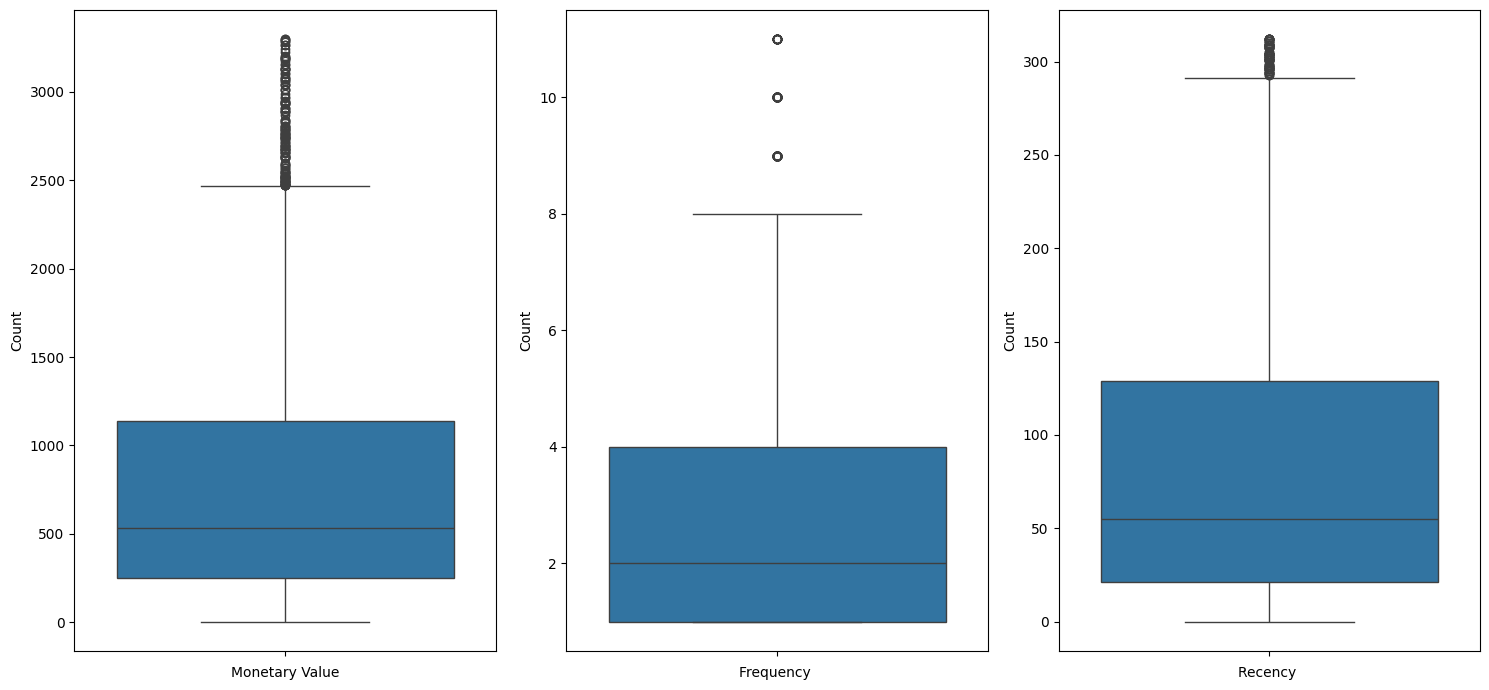

In [32]:
plt.figure(figsize=(15,7))
plt.subplot(1,3,1)
sns.boxplot(non_outlier_df["MonetaryValue"])
plt.xlabel("Monetary Value")
plt.ylabel("Count")

plt.subplot(1,3,2)
sns.boxplot(non_outlier_df["Frequency"])
plt.xlabel("Frequency ")
plt.ylabel("Count")

plt.subplot(1,3,3)
sns.boxplot(non_outlier_df["Recency"])
plt.xlabel("Recency ")
plt.ylabel("Count")


plt.tight_layout()
plt.show()

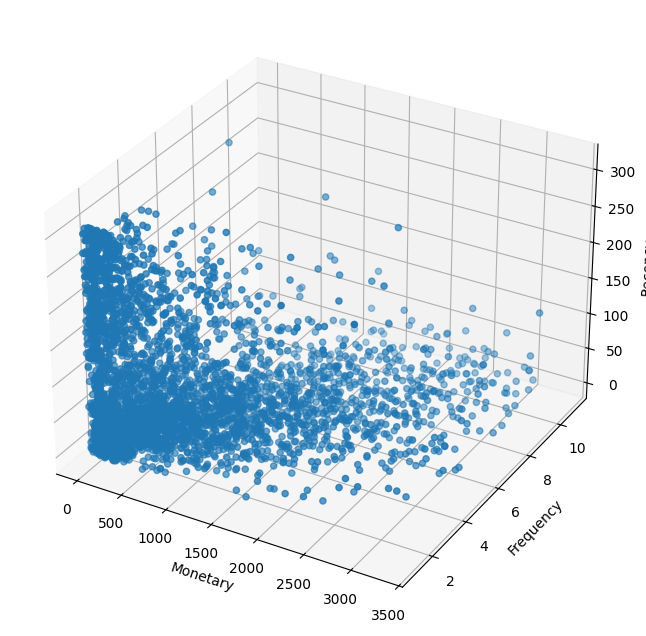

In [33]:
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(projection="3d")
scatter = ax.scatter(non_outlier_df["MonetaryValue"],non_outlier_df["Frequency"],non_outlier_df["Recency"])

ax.set_xlabel("Monetary")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
plt.show()

In [34]:
scalar = StandardScaler()
scaled_data = scalar.fit_transform(non_outlier_df[["MonetaryValue","Frequency","Recency"]])
scaled_data

array([[-0.90777469, -0.41403292,  0.94084866],
       [ 0.2370076 , -0.41403292, -0.99809381],
       [-0.8004544 , -0.85851666, -0.14831039],
       ...,
       [-0.60576419, -0.85851666,  2.50875892],
       [ 0.21117226, -0.41403292,  0.30650328],
       [ 1.0396421 ,  0.47493456, -0.8185621 ]], shape=(3620, 3))

In [35]:
scaled_data = pd.DataFrame(scaled_data,index=non_outlier_df.index,columns=["MonetaryValue","Frequency","Recency"])
scaled_data

,MonetaryValue,Frequency,Recency
0,-0.907775,-0.414033,0.940849
1,0.237008,-0.414033,-0.998094
2,-0.800454,-0.858517,-0.148310
3,1.600103,-0.414033,-0.519343
4,-0.689475,-0.858517,-0.902344
...,...,...,...
4243,-0.324608,1.363902,-0.818562
4244,-0.563777,-0.858517,-0.232092
4245,-0.605764,-0.858517,2.508759
4246,0.211172,-0.414033,0.306503


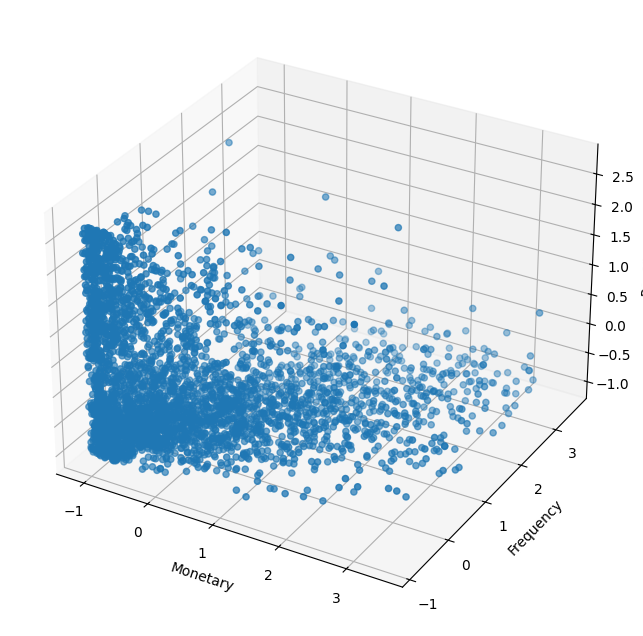

In [41]:
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(projection="3d")
scatter = ax.scatter(scaled_data["MonetaryValue"],scaled_data["Frequency"],scaled_data["Recency"])

ax.set_xlabel("Monetary")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
plt.show()

c:\Users\Alvi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Alvi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Alvi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Alvi\AppData\Local\Python\pythoncore-3.14-64

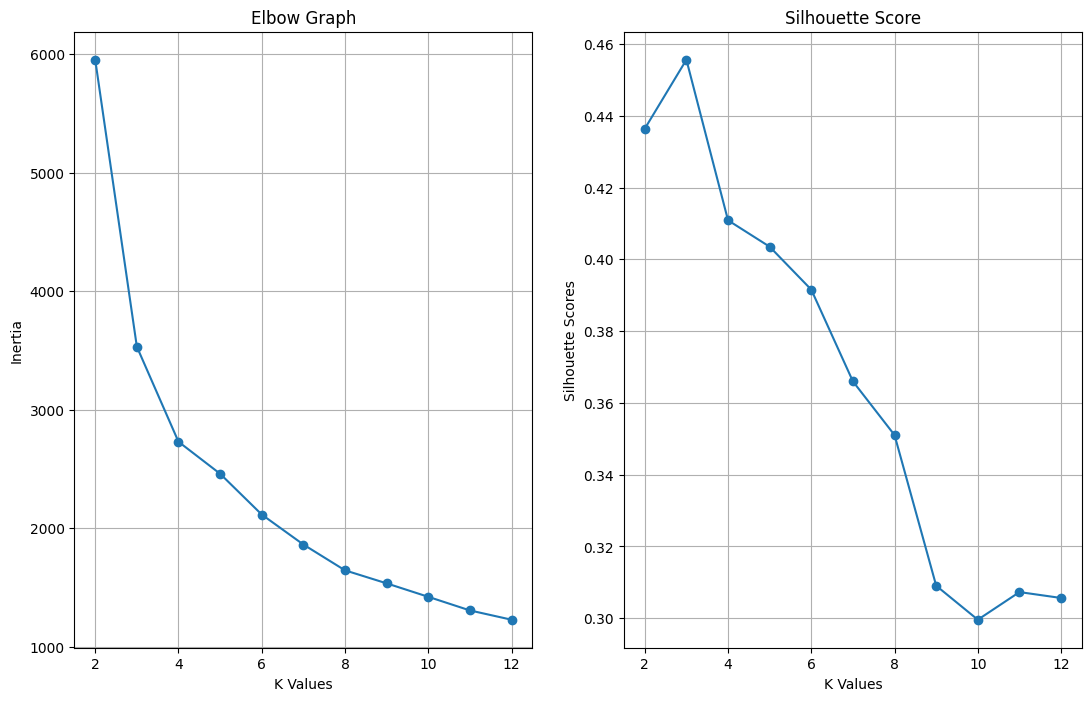

In [36]:
k_values = range(2,13)
inertia = []
silhouette_scores = [] 
for k in k_values:
    kmean = KMeans(n_clusters=k,max_iter=1000,random_state=42)
    cluster_labels = kmean.fit_predict(scaled_data[["MonetaryValue","Frequency","Recency"]])
    sil_score = silhouette_score(scaled_data,cluster_labels)
    silhouette_scores.append(sil_score)
    inertia.append(kmean.inertia_)

plt.figure(figsize=(13,8))

plt.subplot(1,2,1)

plt.plot(k_values,inertia,marker="o")
plt.xlabel("K Values")
plt.ylabel("Inertia")
plt.title("Elbow Graph")
plt.grid(True)

plt.subplot(1,2,2)

plt.plot(k_values,silhouette_scores,marker="o")
plt.xlabel("K Values")
plt.ylabel("Silhouette Scores")
plt.title("Silhouette Score")
plt.grid(True)


plt.show()

- 4 Clusters are best for this data

In [42]:
kmeans = KMeans(n_clusters=4,random_state=42,max_iter=1000)


In [43]:
cluster_labels = kmeans.fit_predict(scaled_data)
cluster_labels

array([3, 1, 1, ..., 3, 1, 0], shape=(3620,), dtype=int32)

In [46]:
non_outlier_df["Clusters"] = cluster_labels
non_outlier_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Clusters
0,12346.0,144.02,2,2010-06-28 13:53:00,164,3
1,12347.0,966.87,2,2010-12-07 14:57:00,2,1
2,12348.0,221.16,1,2010-09-27 14:59:00,73,1
3,12349.0,1946.64,2,2010-10-28 08:23:00,42,0
4,12351.0,300.93,1,2010-11-29 15:23:00,10,1
...,...,...,...,...,...,...
4243,18283.0,563.19,6,2010-11-22 15:30:00,17,0
4244,18284.0,391.28,1,2010-10-04 11:33:00,66,1
4245,18285.0,361.10,1,2010-02-17 10:24:00,295,3
4246,18286.0,948.30,2,2010-08-20 11:57:00,111,1


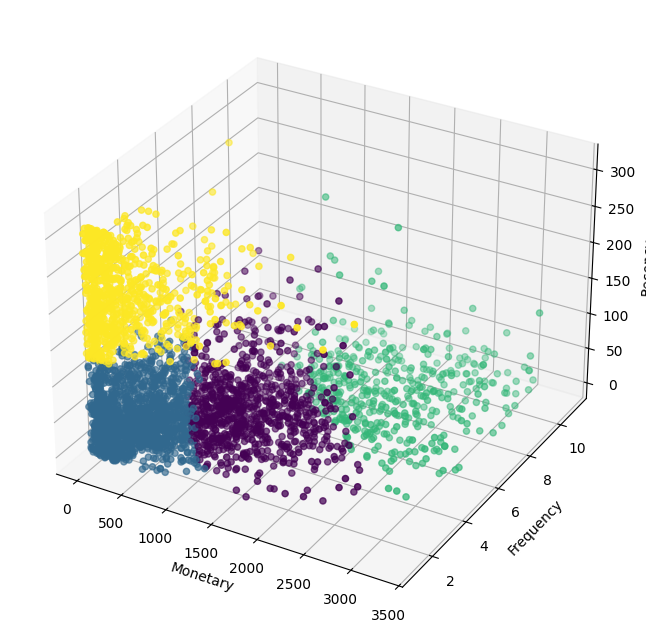

In [48]:
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(projection="3d")
scatter = ax.scatter(non_outlier_df["MonetaryValue"],non_outlier_df["Frequency"],non_outlier_df["Recency"], c=non_outlier_df["Clusters"])

ax.set_xlabel("Monetary")
ax.set_ylabel("Frequency")
ax.set_zlabel("Recency")
plt.show()

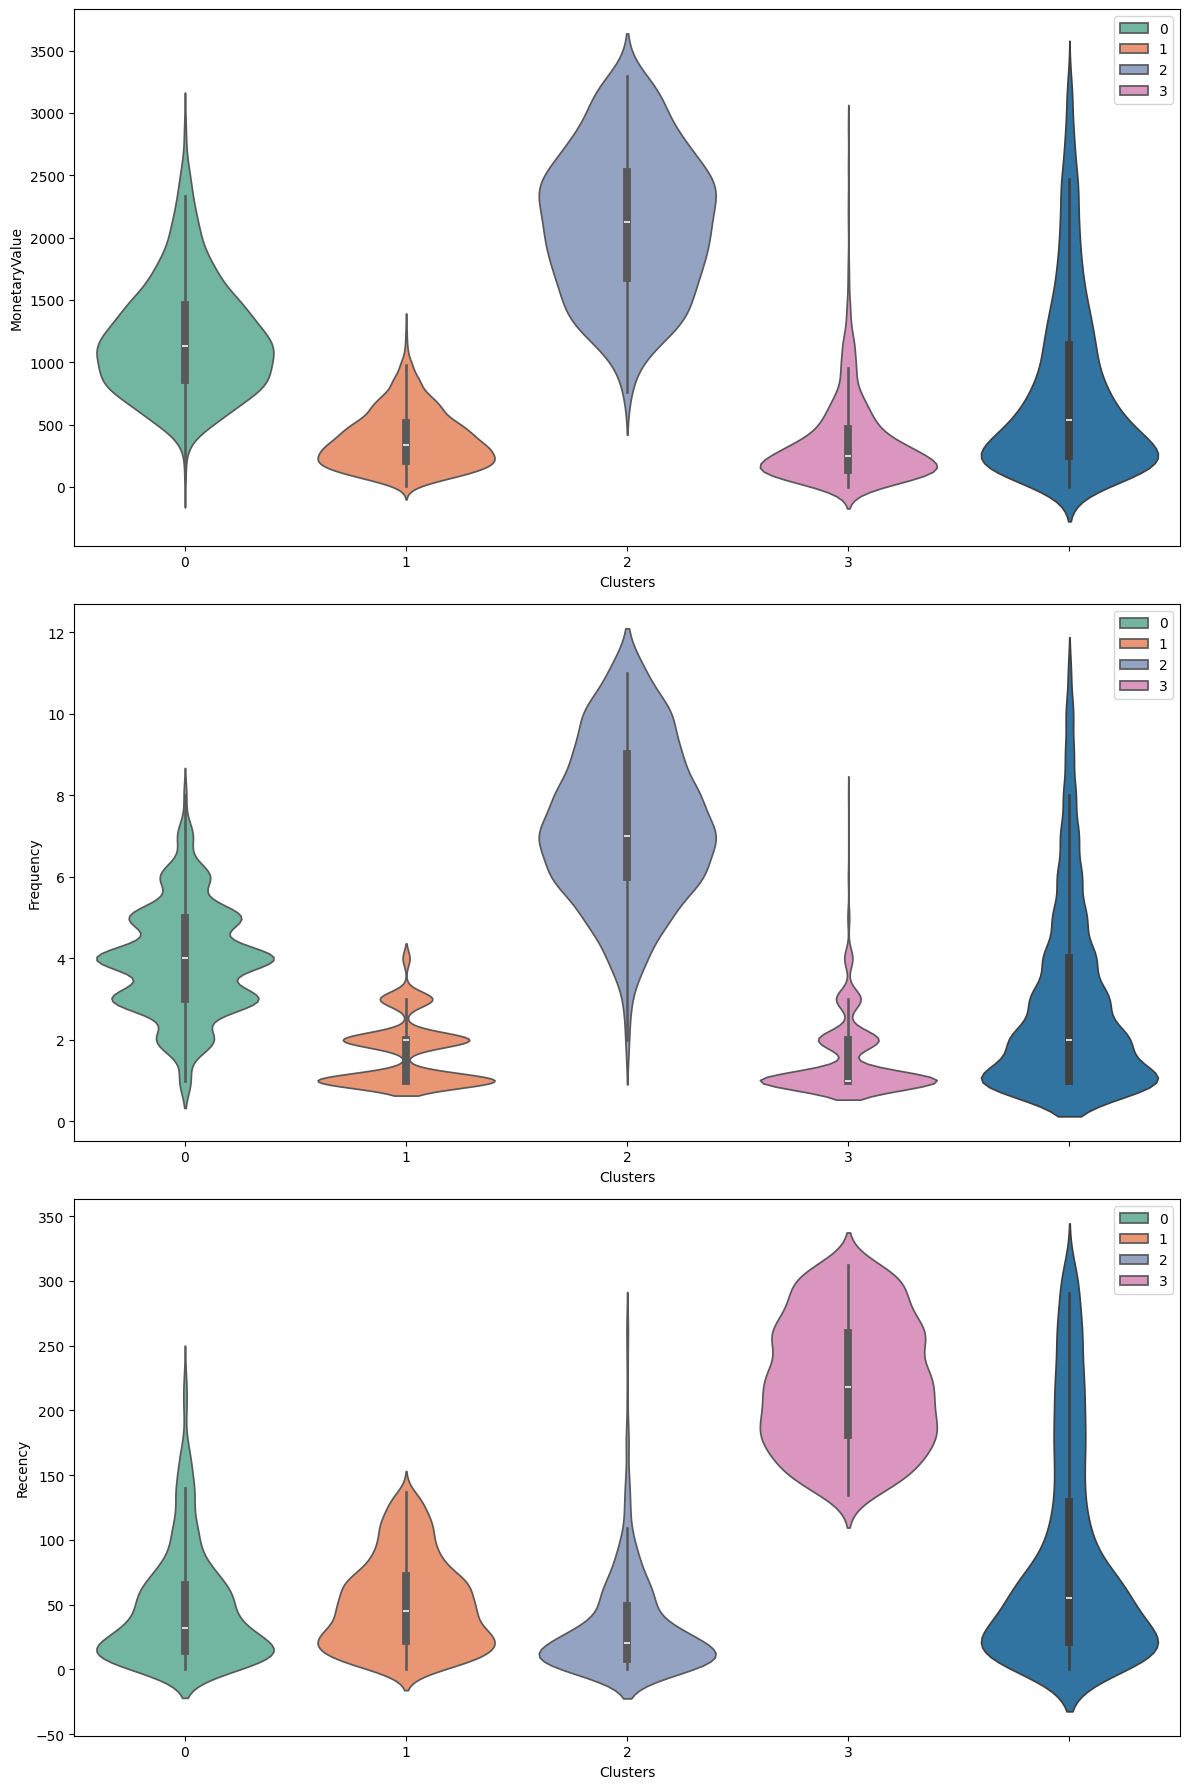

In [54]:
plt.figure(figsize=(12,18))
plt.subplot(3,1,1)
sns.violinplot(x=non_outlier_df["Clusters"],y=non_outlier_df["MonetaryValue"],hue=non_outlier_df["Clusters"],palette="Set2")
sns.violinplot(y=non_outlier_df["MonetaryValue"])
plt.ylabel("MonetaryValue")

plt.subplot(3,1,2)
sns.violinplot(x=non_outlier_df["Clusters"],y=non_outlier_df["Frequency"],hue=non_outlier_df["Clusters"],palette="Set2")
sns.violinplot(y=non_outlier_df["Frequency"])
plt.ylabel("Frequency")

plt.subplot(3,1,3)
sns.violinplot(x=non_outlier_df["Clusters"],y=non_outlier_df["Recency"],hue=non_outlier_df["Clusters"],palette="Set2")
sns.violinplot(y=non_outlier_df["Recency"])
plt.ylabel("Recency")

plt.tight_layout()
plt.show()

### Cluster 0: "Retain"
- Rationale: The customer is high-spending, regualr one though haven't purchased recently. The focis should be on retention efforts to keep thier loyality and spending.
- Action: Personlized offers, regular engagement and loyality prorgram to keep them engaged.

### Cluster 1: "Re-Engage"
- Rationale: The customer is low-spenidng, infrequent buyers and havven't purchased recently. The focus should be on re-engaging them back to active purchases.
- Action: Use targeted market campaigns and special discounts to engage them.

### Cluster 2: "Reward"
- Rationale: The customer is high-spending, freuqnt buyer and still actively purchaing. Thier loyality is key to keep them engage.
- Action: Exclusive offer, loyality program and recognise thier loyality to keep them engaged.

### Cluster 3: "Nurture"
- Rationale: These customer are least-spedning, infrequent but made recent pruchases. These are new customer and need nurtuturing to keep them engage.
- Action: Focus on customer service and provide encentives to encourage them.

## Summary of Clusters
- Cluster 0: "Retain"
- Cluster 1: "Re-Engage"
- Cluster 2: "Reward"
- Cluster 3: "Nurture"

In [59]:
over_lap_outliers_indices = monetary_outlier_df.index.intersection(freq_outlier_df.index)

only_monetary_outlier_df = monetary_outlier_df.drop(over_lap_outliers_indices)
only_freq_outlier_df = freq_outlier_df.drop(over_lap_outliers_indices)
over_laping_outlier = monetary_outlier_df.loc[over_lap_outliers_indices]

only_monetary_outlier_df["Clusters"] = -1
only_freq_outlier_df["Clusters"] = -2
over_laping_outlier["Clusters"] = -3
outlier_cluster_df = pd.concat([only_freq_outlier_df,only_monetary_outlier_df,over_laping_outlier])
outlier_cluster_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Clusters
113,12523.0,2184.25,12,2010-11-30 12:31:00,9,-2
515,13117.0,1466.30,12,2010-12-09 14:50:00,0,-2
594,13230.0,3093.31,17,2010-12-09 19:28:00,0,-2
771,13491.0,2541.06,18,2010-12-02 14:30:00,7,-2
827,13571.0,2265.57,14,2010-11-22 13:09:00,17,-2
...,...,...,...,...,...,...
4199,18223.0,6633.17,12,2010-11-17 12:20:00,22,-3
4200,18225.0,5937.33,15,2010-12-09 15:46:00,0,-3
4201,18226.0,4776.81,15,2010-11-26 15:51:00,13,-3
4205,18231.0,4266.26,23,2010-10-29 14:17:00,41,-3


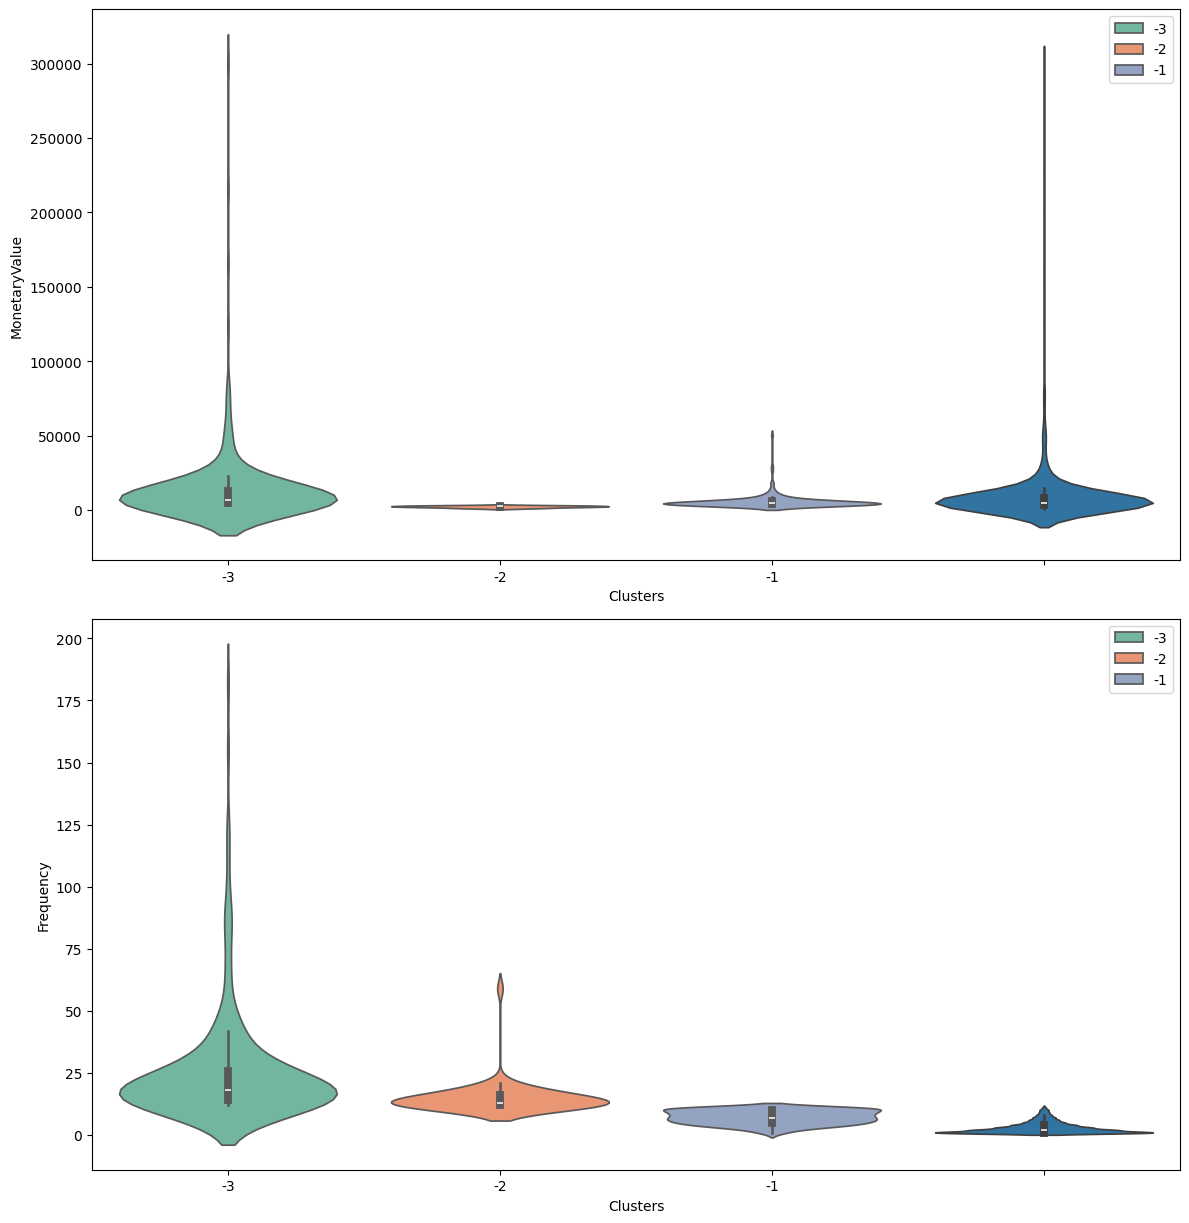

In [ ]:
plt.figure(figsize=(12,18))
plt.subplot(3,1,1)
sns.violinplot(x=outlier_cluster_df["Clusters"],y=outlier_cluster_df["MonetaryValue"],hue=outlier_cluster_df["Clusters"],palette="Set2")
sns.violinplot(y=outlier_cluster_df["MonetaryValue"])
plt.ylabel("MonetaryValue")

plt.subplot(3,1,2)
sns.violinplot(x=outlier_cluster_df["Clusters"],y=outlier_cluster_df["Frequency"],hue=outlier_cluster_df["Clusters"],palette="Set2")
sns.violinplot(y=non_outlier_df["Frequency"])
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Cluster -1: "Pamper"
- Charactristics: High-spending but not frequent buyers.
- Action: Focis on mainting thier loayality and luxury offers.

Cluster -2: "Upsell"
- Charactristics: Low-spednig but freuquent buyers.
- Action: Offer loyality program and bundle deals to encourage thier buyings per visit, given thier frequency.

Cluster -3: "Delight"
- Charactristics: The most valuable outliers. They're top-tier customer. Both frequent and spendings are higher.
- Action: Exclusive offers and special deals to keep thier loyality.


In [62]:
full_clustering_df = pd.concat([outlier_cluster_df,non_outlier_df])
full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Clusters
113,12523.0,2184.25,12,2010-11-30 12:31:00,9,-2
515,13117.0,1466.30,12,2010-12-09 14:50:00,0,-2
594,13230.0,3093.31,17,2010-12-09 19:28:00,0,-2
771,13491.0,2541.06,18,2010-12-02 14:30:00,7,-2
827,13571.0,2265.57,14,2010-11-22 13:09:00,17,-2
...,...,...,...,...,...,...
4243,18283.0,563.19,6,2010-11-22 15:30:00,17,0
4244,18284.0,391.28,1,2010-10-04 11:33:00,66,1
4245,18285.0,361.10,1,2010-02-17 10:24:00,295,3
4246,18286.0,948.30,2,2010-08-20 11:57:00,111,1


In [64]:
cluster_labels = {
    0:"Retain",
    1:"Re_Engage",
    2:"Reward",
    3:"Nuture",
    -1:"Pamper",
    -2:"Upsell",
    -3:"Delight"
}

In [68]:
full_clustering_df["labled_cluster"] = full_clustering_df["Clusters"].map(cluster_labels)
full_clustering_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Clusters,labled_cluster
113,12523.0,2184.25,12,2010-11-30 12:31:00,9,-2,Upsell
515,13117.0,1466.30,12,2010-12-09 14:50:00,0,-2,Upsell
594,13230.0,3093.31,17,2010-12-09 19:28:00,0,-2,Upsell
771,13491.0,2541.06,18,2010-12-02 14:30:00,7,-2,Upsell
827,13571.0,2265.57,14,2010-11-22 13:09:00,17,-2,Upsell
...,...,...,...,...,...,...,...
4243,18283.0,563.19,6,2010-11-22 15:30:00,17,0,Retain
4244,18284.0,391.28,1,2010-10-04 11:33:00,66,1,Re_Engage
4245,18285.0,361.10,1,2010-02-17 10:24:00,295,3,Nuture
4246,18286.0,948.30,2,2010-08-20 11:57:00,111,1,Re_Engage


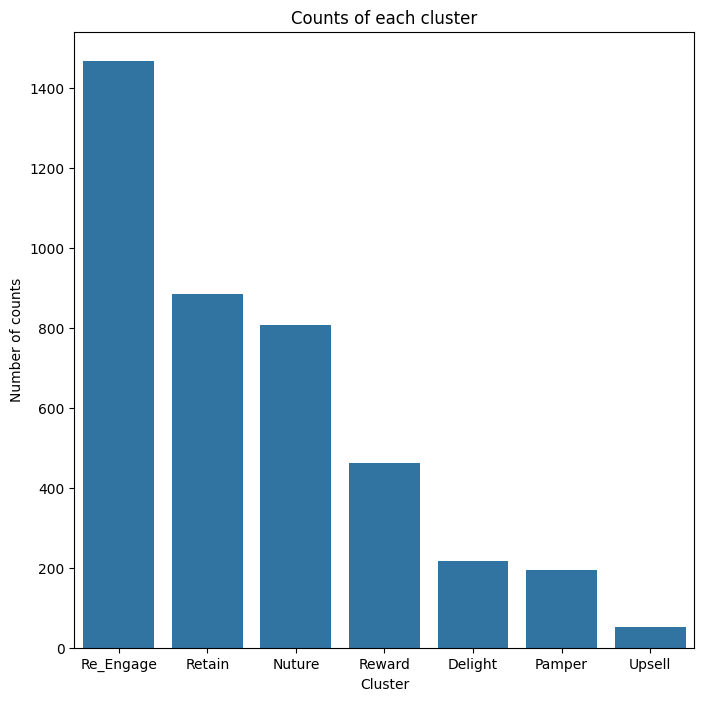

In [71]:
cluster_counts = full_clustering_df["labled_cluster"].value_counts()
plt.figure(figsize=(8,8))
sns.barplot(cluster_counts,)
plt.xlabel("Cluster")
plt.ylabel("Number of counts")
plt.title("Counts of each cluster")
plt.show()